# Data Wrangling — Tiki E-commerce (2 bộ)

Nguồn: [Vietnamese Tiki E-commerce Dataset (Kaggle)](https://www.kaggle.com/datasets/michaelminhpham/vietnamese-tiki-e-commerce-dataset)

1. `vietnamese_tiki_products_men_shoes.csv` — giày nam  
2. `vietnamese_tiki_products_women_shoes.csv` — giày nữ  

Mục tiêu gốc của bộ dữ liệu: dự đoán `quantity_sold`.

Mỗi bước có **1 dòng mẫu**. Dòng `# TODO` em làm tương tự (đổi tên cột / file).

## Download data and explore

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? giá trị lạ (`...`, tab, rỗng)?

| Cột | Ý nghĩa |
|---|---|
| `id` | Mã sản phẩm Tiki |
| `name` | Tên sản phẩm |
| `description` | Mô tả (có thể rỗng / `...`) |
| `original_price` | Giá gốc (VND) |
| `price` | Giá hiện tại (VND) |
| `fulfillment_type` | Hình thức giao: `dropship`, `tiki_delivery`, `seller_delivery` |
| `brand` | Thương hiệu (nhiều `OEM`, đôi khi dính tab `\\tOEM`) |
| `review_count` | Số đánh giá |
| `rating_average` | Điểm trung bình (0–5; 0 thường = chưa có đánh giá) |
| `favourite_count` | Số lượt yêu thích |
| `pay_later` | Có trả sau hay không |
| `current_seller` | Tên shop |
| `date_created` | Số ngày từ lần cập nhật |
| `number_of_images` | Số ảnh |
| `vnd_cashback` | Số tiền hoàn (VND) |
| `has_video` | Có video hay không |
| `category` | Danh mục (`Root` = chưa gán danh mục rõ) |
| `quantity_sold` | Tổng số đã bán (biến mục tiêu) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path_men = "tiki_data/vietnamese_tiki_products_men_shoes.csv"
path_women = "tiki_data/vietnamese_tiki_products_women_shoes.csv"

df_men = pd.read_csv(path_men)  # mẫu: đọc file nam

# TODO: đọc file nữ vào df_women (giống dòng trên, đổi path_women)
df_women = pd.read_csv(path_women)

print("Men shoes:", df_men.shape)  # mẫu: in số dòng, số cột
# TODO: in shape của df_women

df_men.head()  # mẫu: 5 dòng đầu
# TODO: xem 5 dòng đầu df_women

Men shoes: (5745, 19)


,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
0,0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ ...",9900,9900,dropship,OEM,8,3.0,0,False,Rumyh Fashion Style,829,4,268,False,Root,106
1,1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP...,10000,10000,dropship,OEM,0,0.0,0,False,Tổng kho đồ gia dụng QL,504,4,0,False,Root,17
2,2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp ...,9900,9900,dropship,OEM,9,3.2,0,False,sumo98 store,752,6,0,False,Root,83
3,3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠ...,24999,24999,dropship,OEM,0,0.0,0,False,Giày dép Trường Hằng,564,3,0,False,Root,0
4,4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách ...",14200,14200,dropship,OEM,0,0.0,0,False,TT8695,277,9,0,False,Root,0


---
# Bộ 1 — Giày nam

## 1. Xử lý giá trị thiếu (Missing Values)

- Chuỗi rỗng / `...` / `"nan"` → `NaN`.
- `fulfillment_type`, `brand`: cột phân loại → **mode**.
- `description`: điền `""` (không xoá dòng).
- `quantity_sold`: biến mục tiêu → `.dropna(subset=["quantity_sold"])`.

In [2]:
df = df_men.copy()  # mẫu: làm việc trên bản sao

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])  # mẫu: xoá cột index thừa

# TODO: xoá trùng theo id rồi reset_index — gợi ý: drop_duplicates(subset=["id"])
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)

for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()  # mẫu: cắt khoảng trắng 2 đầu

    # TODO: trong vòng for, replace {"nan": np.nan, "": np.nan, "...": np.nan} cho df[c]
    df[c] = df[c].replace({"nan": np.nan, "": np.nan, "...": np.nan})
df["brand"] = df["brand"].str.replace("\t", "", regex=False)  # mẫu: xoá tab trong brand

print(df.isnull().sum())  # mẫu: đếm missing trước xử lý

df["fulfillment_type"] = df["fulfillment_type"].fillna(
    df["fulfillment_type"].mode(dropna=True)[0]
)  # mẫu: cột chữ → điền mode

# TODO: fillna mode cho cột brand (copy mẫu, đổi tên cột)
df['brand'] = df['brand'].fillna(df['brand'].mode(dropna=True)[0])

# TODO: df["description"] fillna bằng ""
df['description'] = df['description'].fillna(df['description'].mode(dropna=True)[0])

# TODO: dropna subset=["quantity_sold"] rồi reset_index
df['quantity_sold'] = df['quantity_sold'].dropna().reset_index(drop=True)

# TODO: in lại isnull().sum() sau khi xử lý
print(df.isnull().sum())

id                    0
name                  0
description         258
original_price        0
price                 0
fulfillment_type      1
brand                 0
review_count          0
rating_average        0
favourite_count       0
pay_later             0
current_seller        0
date_created          0
number_of_images      0
vnd_cashback          0
has_video             0
category              0
quantity_sold         0
dtype: int64
id                  0
name                0
description         0
original_price      0
price               0
fulfillment_type    0
brand               0
review_count        0
rating_average      0
favourite_count     0
pay_later           0
current_seller      0
date_created        0
number_of_images    0
vnd_cashback        0
has_video           0
category            0
quantity_sold       0
dtype: int64


## 2. Sửa định dạng dữ liệu (Correct Data Format)

In [3]:
print(df.dtypes)  # mẫu: xem kiểu hiện tại
print()
df["price"] = df["price"].astype(int)  # mẫu: ép price về int

# TODO: ép original_price, quantity_sold, review_count về int (giống dòng trên)
df['original_price'] = df['original_price'].astype(int)
df['quantity_sold'] = df['quantity_sold'].astype(int)
df['review_count'] = df['review_count'].astype(int)

# TODO: ép rating_average về float
df['rating_average'] = df['rating_average'].astype(float)  

# TODO: print dtypes các cột vừa ép
print(df.dtypes[['price', 'original_price', 'quantity_sold', 'review_count', 'rating_average']])

id                    int64
name                 object
description          object
original_price        int64
price                 int64
fulfillment_type     object
brand                object
review_count          int64
rating_average      float64
favourite_count       int64
pay_later              bool
current_seller       object
date_created          int64
number_of_images      int64
vnd_cashback          int64
has_video              bool
category             object
quantity_sold         int64
dtype: object

price               int64
original_price      int64
quantity_sold       int64
review_count        int64
rating_average    float64
dtype: object


## 3. Chuẩn hoá dữ liệu (Data Standardization)

Giá đang là **VND**. Đổi sang **nghìn đồng** cho dễ đọc, và tính **% giảm giá** so với giá gốc.

In [4]:
df["price_nghin"] = df["price"] / 1000  # mẫu: VND → nghìn đồng

# TODO: cột original_price_nghin = original_price / 1000
df['original_price_nghin'] = df['original_price'] / 1000

# TODO: cột discount_pct = (original_price - price) / original_price * 100
#       dùng np.where(original_price > 0, công_thức, 0)
df['discount_pct'] = np.where(df['original_price'] > 0, (df['original_price'] - df['price']) / df['original_price'] * 100, 0)

df[["price", "price_nghin"]].head()  # mẫu: xem kết quả

# TODO: head thêm original_price và discount_pct
print(df[['original_price', 'original_price_nghin', 'discount_pct']].head())

   original_price  original_price_nghin  discount_pct
0            9900                 9.900           0.0
1           10000                10.000           0.0
2            9900                 9.900           0.0
3           24999                24.999           0.0
4           14200                14.200           0.0


## 4. Chuẩn hoá phạm vi giá trị (Data Normalization)

`price` và `quantity_sold` lệch thang đo rất mạnh → `x / x.max()` về 0–1.

In [5]:
df["price_normalized"] = df["price"] / df["price"].max()
  # mẫu: chia max → 0–1
# TODO: quantity_sold_normalized = quantity_sold / max
df['quantity_sold_normalized'] = df['quantity_sold'] / df['quantity_sold'].max()

# TODO: review_count_normalized = review_count / max
df['review_count_normalized'] = df['review_count'] / df['review_count'].max()
df[["price", "price_normalized"]].head()  # mẫu

# TODO: head thêm quantity_sold và cột normalize tương ứng
print(df[['quantity_sold', 'quantity_sold_normalized', 'review_count', 'review_count_normalized']].head())

   quantity_sold  quantity_sold_normalized  review_count  \
0            106                  0.019525             8   
1             17                  0.003131             0   
2             83                  0.015288             9   
3              0                  0.000000             0   
4              0                  0.000000             0   

   review_count_normalized  
0                 0.008256  
1                 0.000000  
2                 0.009288  
3                 0.000000  
4                 0.000000  


## 5. Phân nhóm (Binning)

Chia giá thành Low / Medium / High theo ngưỡng VND thực tế (không dùng min–max đều vì giá max rất lớn, hầu hết sản phẩm sẽ rơi vào Low).

price_binned
Medium    2862
Low       1855
High      1027
Name: count, dtype: int64


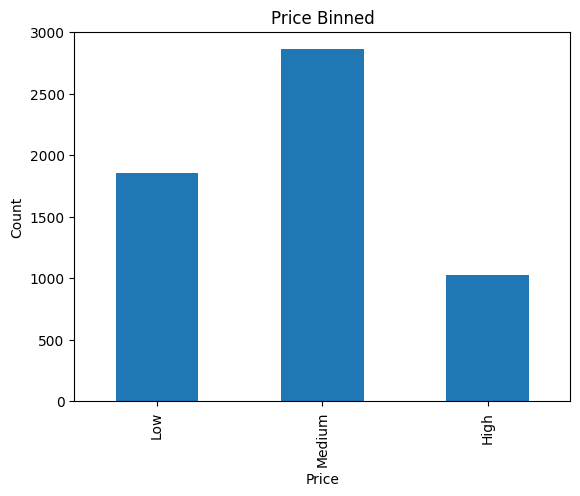

,price,price_binned
0,9900,"Axes(0.125,0.11;0.775x0.77)"
1,10000,"Axes(0.125,0.11;0.775x0.77)"
2,9900,"Axes(0.125,0.11;0.775x0.77)"
3,24999,"Axes(0.125,0.11;0.775x0.77)"
4,14200,"Axes(0.125,0.11;0.775x0.77)"


In [6]:
price_bins = [0, 100_000, 500_000, df["price"].max() + 1]  # mẫu: 3 khoảng giá

df["price_binned"] = pd.cut(
    df["price"], bins=price_bins, labels=["Low", "Medium", "High"], include_lowest=True
)  # mẫu: gán nhãn Low / Medium / High

print(df["price_binned"].value_counts())  # mẫu: đếm mỗi nhóm

# TODO: vẽ bar — gợi ý: df["price_binned"].value_counts().sort_index().plot(kind="bar")
df['price_binned'] = df['price_binned'].value_counts().sort_index().plot(kind='bar')

# TODO: plt.xlabel / ylabel / title rồi plt.show()
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Binned")
plt.show()
df[["price", "price_binned"]].head()

## 6. Biến chỉ thị / Biến giả (Dummy Variable)

`fulfillment_type` (chữ) → mỗi hình thức giao một cột 0/1 bằng `pd.get_dummies()`, rồi xoá cột gốc.

In [7]:
dummy_ff = pd.get_dummies(df["fulfillment_type"], prefix="fulfillment", dtype=int)  # mẫu: cột 0/1

# TODO: gộp dummy vào df — pd.concat([df, dummy_ff], axis=1)
df = pd.concat([df, dummy_ff], axis=1)

# TODO: xoá cột gốc — df.drop(columns=["fulfillment_type"])
df = df.drop(columns=["fulfillment_type"])
df.head()  # mẫu: kiểm tra bảng

,id,name,description,original_price,price,brand,review_count,rating_average,favourite_count,pay_later,...,price_nghin,original_price_nghin,discount_pct,price_normalized,quantity_sold_normalized,review_count_normalized,price_binned,fulfillment_dropship,fulfillment_seller_delivery,fulfillment_tiki_delivery
0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất Nh...",9900,9900,OEM,8,3.0,0,False,...,9.900,9.900,0.0,0.000673,0.019525,0.008256,"Axes(0.125,0.11;0.775x0.77)",1,0,0
1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP SẼ GIA...,10000,10000,OEM,0,0.0,0,False,...,10.000,10.000,0.0,0.000680,0.003131,0.000000,"Axes(0.125,0.11;0.775x0.77)",1,0,0
2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp dép êm ...,9900,9900,OEM,9,3.2,0,False,...,9.900,9.900,0.0,0.000673,0.015288,0.009288,"Axes(0.125,0.11;0.775x0.77)",1,0,0
3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠI DÀY/M...,24999,24999,OEM,0,0.0,0,False,...,24.999,24.999,0.0,0.001701,0.000000,0.000000,"Axes(0.125,0.11;0.775x0.77)",1,0,0
4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách sạn/Đi ...",14200,14200,OEM,0,0.0,0,False,...,14.200,14.200,0.0,0.000966,0.000000,0.000000,"Axes(0.125,0.11;0.775x0.77)",1,0,0


## Check and save

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ cố ý để thiếu)
* `price`, `quantity_sold` là số
* có cột mới: `price_nghin`, `*_normalized`, `price_binned`, `fulfillment_*`

`index=False` để file không thêm cột index 0,1,2,…


In [8]:
df.to_csv("tiki_men_shoes_clean.csv", index=False)  # mẫu: lưu file nam
print(df.shape)

# TODO: gán df_men_clean = df để giữ bản sạch bộ nam
df_men_clean = df

(5744, 27)


---
---
# Bộ 2 — Giày nữ

Làm **giống bộ nam**, đổi `df_men` → `df_women`. Copy mẫu ở trên, sửa tên biến. Kết thúc bằng **Check and save** (`to_csv`, `index=False`).


In [9]:
df = df_women.copy()  # mẫu: bắt đầu từ file nữ

# TODO: drop Unnamed: 0 (if có), drop_duplicates id, reset_index — copy bộ nam
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)

# TODO: strip + replace nan/""/"..." trên cột object; xoá \t ở brand
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({"nan": np.nan, "": np.nan, "...": np.nan})
df["brand"] = df["brand"].str.replace("\t", "", regex=False)

# TODO: fillna mode fulfillment_type (đã có mẫu bộ nam) và brand; description → ""
df['fulfillment_type '] = df['fulfillment_type'].fillna(df['fulfillment_type'].mode(dropna=True)[0])
df['brand'] = df['brand'].fillna(df['brand'].mode(dropna=True)[0])
df['description'] = df['description'].fillna(df['description'].mode(dropna=True)[0])

# TODO: dropna quantity_sold, reset_index, in isnull().sum() lần nữa
df['quantity_sold'] = df['quantity_sold'].dropna().reset_index(drop=True)
print(df.isnull().sum())

id                   0
name                 0
description          0
original_price       0
price                0
fulfillment_type     0
brand                0
review_count         0
rating_average       0
favourite_count      0
pay_later            0
current_seller       0
date_created         0
number_of_images     0
vnd_cashback         0
has_video            0
category             0
quantity_sold        0
fulfillment_type     0
dtype: int64


price_binned
Medium    3118
Low       2207
High       592
Name: count, dtype: int64


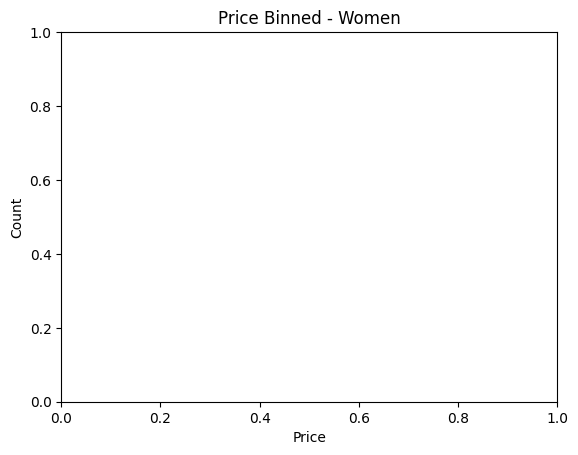

(5917, 28)


In [10]:
df["price"] = df["price"].astype(int)  # mẫu bước 2
# TODO: ép các cột số còn lại (như bộ nam)
df['original_price'] = df['original_price'].astype(int)
df['quantity_sold'] = df['quantity_sold'].astype(int)
df['review_count'] = df['review_count'].astype(int)

df["price_nghin"] = df["price"] / 1000  # mẫu bước 3
# TODO: original_price_nghin và discount_pct
df['original_price_nghin'] = df['original_price'] / 1000
df['discount_pct'] = np.where(df['original_price'] > 0, (df['original_price'] - df['price']) / df['original_price'] * 100, 0)

df["price_normalized"] = df["price"] / df["price"].max()  # mẫu bước 4
# TODO: normalize quantity_sold và review_count
df['quantity_sold_normalized'] = df['quantity_sold'] / df['quantity_sold'].max()
df['review_count_normalized'] = df['review_count'] / df['review_count'].max()

# TODO: bước 5 — pd.cut + value_counts + plot (copy mẫu bộ nam, đổi title Women)
df['price_binned'] = pd.cut(df["price"], bins=price_bins, labels=["Low", "Medium", "High"], include_lowest=True)
print(df["price_binned"].value_counts())
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Binned - Women")
plt.show()

dummy_ff = pd.get_dummies(df["fulfillment_type"], prefix="fulfillment", dtype=int)  # mẫu bước 6
# TODO: concat + drop fulfillment_type
df = pd.concat([df, dummy_ff], axis=1)
df = df.drop(columns=["fulfillment_type"])

# TODO: to_csv tiki_women_shoes_clean.csv; print shape; df.head()
df.to_csv("tiki_women_shoes_clean.csv", index=False) 
print(df.shape)
df_women_clean = df